# [Project] ResNet 아키텍처 분석 및 Residual Connection 효과 검증

본 프로젝트는 **ResNet-34** 및 **ResNet-50** 모델을 직접 구현하고, 잔차 학습(Residual Learning)의 핵심인 **쇼트컷(Shortcut) 구조**가 모델의 성능과 수렴 속도에 미치는 영향을 비교 분석하는 것을 목적으로 합니다.

---

## 📂 목차 (Table of Contents)

## **1. 실험 환경 설정 및 라이브러리 로드**

## **2. 데이터 전처리 및 Oxford-IIIT Pet 데이터셋 구축**
* **2.1. 데이터 전처리 (Transforms)**
* **2.2. 데이터셋 로드 및 배치 설정**
* **2.3. 샘플 데이터 구조 및 클래스 정보 확인**
* **2.4. 데이터셋 규모 및 학습 환경 분석**
* **2.5. 전처리 결과 검증 및 데이터 시각화**

## **3. ResNet 아키텍처 설계 및 구현**
* **3.1. ResNet-34를 위한 BasicBlock 클래스 정의**
* **3.2. 아블레이션 실험을 위한 Plain Block (No Shortcut) 정의**
* **3.3. ResNet-50을 위한 BottleneckBlock 클래스 정의**
* **3.4. ResNet-50 아블레이션 실험을 위한 Bottleneck Plain Block 정의**
* **3.5. 가변적 구조 설계를 위한 통합 ResNet 클래스 구현**

## **4. 실험 모델 인스턴스화 및 아키텍처 검증**
* **4.1. 실험군 및 대조군 모델 생성**
* **4.2. 아키텍처 요약(Summary) 및 분석 포인트** `🎯 루브릭 1: 모델 구현 확인`
    * 4.2.1. 결과 분석: 모델 간 파라미터 효율성 비교
    * 4.2.2. 결과 분석: ResNet-34 vs ResNet-50 구조적 차이점
* **4.3. 실험 가설 및 기대 결과 (Experimental Hypothesis)**

## **5. 실험 설계 및 통합 학습 루틴 정의**
* **5.1. 하드웨어 가속(GPU) 환경 검증**
* **5.2. 하이퍼파라미터 설정 및 통합 학습 함수(Trainer) 정의**

## **6. 실험 결과 분석 및 고찰**
* **6.1. 모델별 학습 수치 데이터 요약 (Tabular Analysis)** `📊 루브릭 2, 3: 테이블 비교`
* **6.2. 가설 기반 시각화 분석 (Hypothesis-specific Visualization)** `📈 루브릭 2, 3: 그래프 분석`
* **6.3. 실험 결과 종합 분석 및 고찰 (Final Discussion)**

## **7. 심화 추가 실험: 모델 깊이에 따른 과적합 임계점 정밀 분석**
* **7.1. 추가 실험 상세 설계(40 Epoch 확장 학습)**
* **7.2. 핵심 분석 전략: 고정 학습률(Fixed LR) 하의 수렴 양상 비교**
* **7.3. 모델별 학습 수치 데이터 요약 (Tabular Analysis)**
* **7.4. 가설 기반 시각화 분석 (Hypothesis-specific Visualization)**
* **7.5. 확장 학습 결과 최종 분석 및 가설 검증 (Post-hoc Analysis)**

## **8. 프로젝트 회고: ResNet Ablation Study**

---

## 1. 실험 환경 설정 및 라이브러리 로드
* **Framework**: `PyTorch`를 기반으로 신경망을 설계합니다.
* **Dataset**: `torchvision`을 통해 Oxford-IIIT Pet 데이터셋을 활용합니다.
* **Analysis Tool**: `torchinfo`를 사용하여 모델의 레이어 구조와 파라미터 수를 상세히 확인합니다.
* **Visualization**: `matplotlib`과 `numpy`를 활용하여 학습 결과(Loss, Accuracy)를 시각화합니다.

In [1]:
# Pytorch 라이브러리 로드
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
!pip install torchinfo
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. 데이터 전처리 및 Oxford-IIIT Pet 데이터셋 구축
실험에 사용할 이미지를 신경망 학습에 최적화된 형태로 변환하는 **전처리 파이프라인**을 구축합니다.

### 2.1. 데이터 전처리 (Transforms)
* **Resize (224x224)**: ResNet의 표준 입력 크기에 맞춰 모든 이미지를 동일한 해상도로 조정합니다. 이는 모델의 연산 그래프를 유지하기 위한 필수 단계입니다.
* **Normalization**: ImageNet 데이터셋의 평균(`mean`)과 표준편차(`std`)를 적용하여 정규화를 수행합니다. 이는 모델 학습 시 그래디언트가 안정적으로 전달되도록 돕습니다.

### 2.2. 데이터셋 로드 및 배치 설정
* **Oxford-IIIT Pet**: 37종의 개와 고양이 품종으로 구성된 데이터셋을 `trainval`(학습용)과 `test`(평가용)로 구분하여 로드합니다.
* **DataLoader**: 효율적인 메모리 사용과 연산 속도를 위해 데이터를 Batch 단위(32)로 나누어 처리하며, 학습 데이터는 매 에포크마다 섞이도록(`shuffle=True`) 설정합니다.

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # <--- 이 줄이 반드시 추가되어야 에러가 안 납니다!
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # 보통 이 값(ImageNet 표준)을 씁니다.
])


# CIFAR10과 달리 train=True 대신 split='trainval' / 'test'를 사용합니다.
trainset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform)
testset = torchvision.datasets.OxfordIIITPet(root='./data', split='test', download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

### 2.3. 샘플 데이터 구조 및 클래스 정보 확인
학습 데이터셋의 개별 샘플을 추출하여 모델의 입력 차원과 라벨링 체계를 확인합니다. 이는 모델 아키텍처의 입력 레이어와 최종 출력 레이어(Fully Connected Layer)를 설계하는 기준이 됩니다.

* **Image Shape**: `(3, 224, 224)` 형태의 텐서로 확인되며, 이는 3채널(RGB) 컬러 이미지와 전처리 과정에서 설정한 해상도를 나타냅니다.
* **Class Names**: 총 37종의 반려동물 품종으로 구성되어 있으며, 각 인덱스에 해당하는 품종 명칭을 통해 학습 결과를 직관적으로 해석할 수 있도록 합니다.

In [3]:
# 데이터셋을 로드하고 기본 정보를 확인해 보세요.
image, label = trainset[0] #0번째 데이터를 이미지와 레이블로 나눠서 변수화
class_names = trainset.classes
print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")
print(f"class_names : {class_names}")

Image shape: torch.Size([3, 224, 224])
Label: 0
Number of classes: 37
class_names : ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


### 2.4. 데이터셋 규모 및 학습 환경 분석
학습 및 테스트에 가용한 전체 데이터의 개수를 파악합니다. 이는 모델의 복잡도(Capacity)와 학습 전략을 결정하는 핵심 지표입니다.

* **Dataset Split**: 훈련 데이터 3,680장, 테스트 데이터 3,669장으로 구성된 표준 분할(Standard Split) 방식을 따릅니다.
* **데이터 희소성 분석**: 클래스당 할당된 데이터가 약 100장 내외로, 딥러닝 모델을 바닥부터(From Scratch) 학습시키기에 상당히 도전적인 규모입니다. 이러한 환경은 **ResNet-50과 같이 파라미터가 많은 모델에서 과적합(Overfitting)을 유발**할 수 있는 주요 요인이 됩니다.

In [4]:
# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 3680 (Shape: torch.Size([]))
Test dataset size: 3669 (Shape: torch.Size([]))


### 2.5. 전처리 결과 검증 및 데이터 시각화
수치화된 텐서 데이터를 시각적인 이미지로 복원하여, 구축된 전처리 파이프라인(Transforms)이 의도대로 작동하는지 검증합니다.

* **역정규화(Denormalization)**: 모델 학습 효율을 위해 표준화(`Normalize`)했던 데이터를 시각화를 위해 다시 원본 스케일로 복원하는 함수를 정의합니다.
* **차원 재배열 (Permute)**: PyTorch 텐서의 차원 구조`(Channel, Height, Width)`를 시각화 라이브러리인 Matplotlib의 규격`(Height, Width, Channel)`에 맞게 변환합니다.
* **배치(Batch) 시각화**: 학습 및 테스트 데이터로더(DataLoader)에서 무작위 샘플을 추출하여 이미지와 라벨의 일치 여부를 최종적으로 확인합니다.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55038965..1.6792717].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48189062..1.5149891].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5178571..1.453987].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.33633018..1.8112855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55038965..1.6108497].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49159664..1.4627016].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55

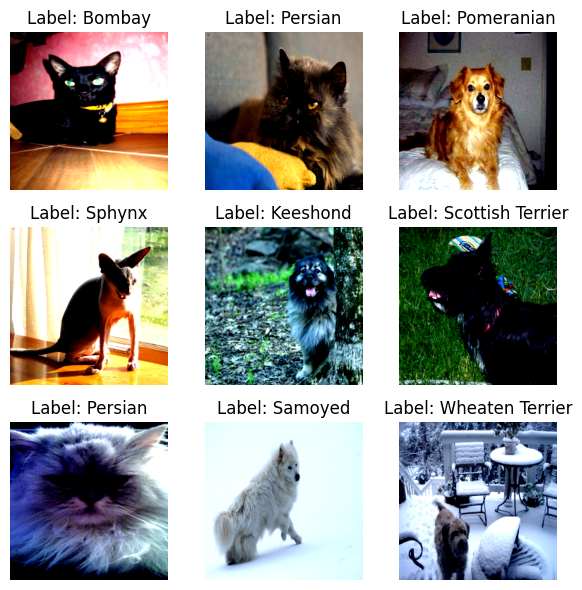

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.55038965..1.6631372].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4390756..1.6967788].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5161401..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.46476585..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.490453..1.6021352].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].
Clippi

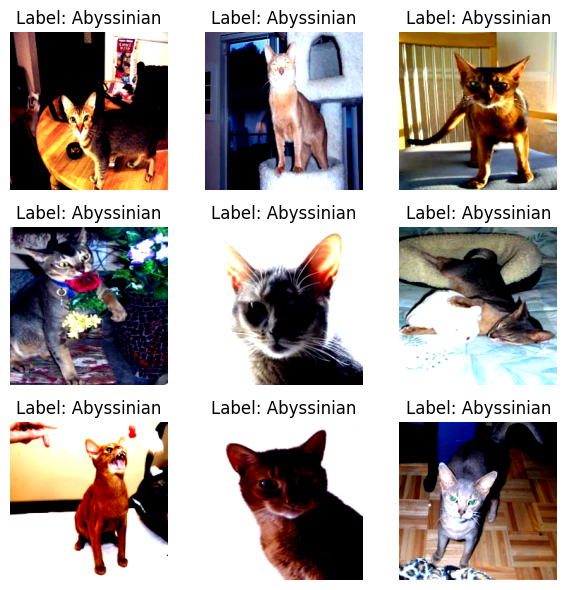

In [5]:
#데이터 세트 시각화

#텐서형태 데이터를 역정규화 후 np array로 변환
def imshow(img):
    img = img / 2 + 0.5 #역정규화 과정(결과값 = (원본 - 평균) / 표준편차 --> 원본=  결과값*0.5+0.5)
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))#mathplot에 맞게 변수 순서 변경(채널을 맨 뒤로)


#매스플랏으로 시각화
def show_multiple_images(dataset, n_images=9):
    dataiter = iter(dataset)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow(images[i])
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()


 # 학습 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(trainloader)

# 테스트 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(testloader)

## 3. ResNet 아키텍처 설계 및 구현

### 3.1. ResNet-34를 위한 BasicBlock 클래스 정의
ResNet-34의 기본 단위인 **BasicBlock**을 구현합니다. 이 블록은 두 개의 $3 \times 3$ 컨볼루션 레이어로 구성되며, 입력값을 출력값에 직접 더해주는 **Shortcut Connection**을 통해 깊은 망에서도 기울기 소실 문제 없이 학습이 가능하게 합니다.

#### 💡 설계 핵심 포인트
1. **잔차 학습(Residual Learning)**: `out += self.shortcut(x)` 연산을 통해 모델이 입력과 출력 사이의 잔차(Residual)만을 학습하도록 유도합니다. 이는 단순한 항등 함수(Identity Mapping) 학습을 최적화의 목표로 설정하여 학습 난이도를 낮춥니다.
2. **차원 일치(Dimension Matching)**: 입력과 출력의 채널 수나 해상도(Stride)가 다를 경우, `shortcut` 경로에 $1 \times 1$ 컨볼루션을 배치하여 차원을 강제로 일치시킵니다.
3. **연산 효율성**: 
   * `bias=False`: BatchNorm 레이어가 뒤따를 경우 가중치의 편향(Bias)은 정규화 과정에서 상쇄되므로, 메모리와 연산 효율을 위해 제거합니다.
   * `expansion=1`: BasicBlock은 Bottleneck 구조와 달리 채널 확장 없이 설계를 유지합니다.

In [3]:
#레즈넷 기본블록 클래스 만들기

class BasicBlock(nn.Module): 
    expansion=1     #기본블럭은 확장을 하지 않으니 expansion=1

    #블럭의 기본 흐름 : 콘 배 렐 콘 배 쇼트컷 렐
    def __init__(self, in_channels, out_channels, stride=1): #이 블록의 변수는 입력 채널, 출력채널, 보폭 3개임
        super().__init__()
        self.conv1 =nn.Conv2d(
            in_channels, out_channels, 
            kernel_size=3, stride=stride, padding=1, bias=False #뒤에 BN이 오면 바이어스는 false로 해야함. bias해봣자 BN하면 상쇄되서 굳이 할 필요없음(메모리낭비)
            )
        self.bn1 = nn.BatchNorm2d(out_channels) 
        self.relu = nn.ReLU(True) 
        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
             kernel_size=3, stride=1, padding=1, bias=False
             )
        self.bn2 = nn.BatchNorm2d(out_channels)

        #레즈넷 핵심 쇼트컷
        self.shortcut = nn.Sequential()                                 #별 일 없으면 그냥 원본 불러오기

         #스트라이드가 1이 아니거나 채널수가 2배가 됐을땐 스트라이드를 동일하게 가져가고 채널수도 늘림. 각 층 첫 레이어에서 인채널보다 아웃채널이 2배 큼
        if stride != 1 or in_channels != self.expansion*out_channels:  
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, self.expansion*out_channels,           #1*1 콘브를 하지만 채널수를 2배로 늘려줌
                    kernel_size=1, stride=stride, bias=False            #스트라이드를 2로 해서 크기를 줄여줌
                ),
                nn.BatchNorm2d(self.expansion*out_channels)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)         #괄호 안에 x가 들어가는게 핵심. 아웃에 계속 층을 쌓다가 여기서 x를 넣어줌
        out = self.relu(out)
        return out



### 3.2. 아블레이션 실험을 위한 Plain Block (No Shortcut) 정의
ResNet의 핵심 혁신 요소인 잔차 연결(Residual Connection)의 효과를 정량적으로 검증하기 위해, 쇼트컷이 제거된 **Plain 구조의 블록**을 정의합니다.

#### 🧪 실험 설계 의도
1. **대조군 설정**: `BasicBlock`에서 `self.shortcut`과 `out += x` 연산만을 제거하여, 네트워크의 깊이와 파라미터 수는 거의 동일하게 유지한 채 **'연결 방식'에 따른 성능 차이**만을 고립시켜 관찰합니다.
2. **퇴화 문제(Degradation Problem) 재현**: 쇼트컷이 없을 때 층이 깊어짐에 따라 발생하는 퇴화 문제(Degradiation Problem)와 그로 인해 학습이 정체되는 현상을 의도적으로 유도합니다.
3. **가설 검증**: 앞서 세운 "쇼트컷이 없으면 깊은 층에서 길을 잃어 오리지널보다 정확도가 낮을 것"이라는 가설을 확인하기 위한 핵심 모듈입니다.

#### 🛠 구조적 특징
* **단순 적층(Plain Stacking)**: 입력값이 출력값에 더해지는 과정 없이, 오직 컨볼루션 연산의 결과물만이 다음 층으로 전달되는 전통적인 CNN 구조를 따릅니다.
* **파라미터 일치**: 연산에 관여하는 컨볼루션 레이어와 배치 정규화(BN) 층의 구성은 오리지널 블록과 동일하므로, 모델의 체급 차이에 의한 변수를 최소화했습니다.

In [4]:
#레즈넷 아블레이션 기본블록 클래스 만들기

class BasicBlock_no_shortcut(nn.Module): 
    expansion=1     #기본블럭은 확장을 하지 않으니 expansion=1

    #블럭의 기본 흐름 : 콘 배 렐 콘 배 쇼트컷 렐
    def __init__(self, in_channels, out_channels, stride=1): #이 블록의 변수는 입력 채널, 출력채널, 보폭 3개임
        super().__init__()
        self.conv1 =nn.Conv2d(
            in_channels, out_channels, 
            kernel_size=3, stride=stride, padding=1, bias=False #뒤에 BN이 오면 바이어스는 false로 해야함. bias해봣자 BN하면 상쇄되서 굳이 할 필요없음(메모리낭비)
            )
        self.bn1 = nn.BatchNorm2d(out_channels) 
        self.relu = nn.ReLU(True) 
        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
             kernel_size=3, stride=1, padding=1, bias=False
             )
        self.bn2 = nn.BatchNorm2d(out_channels)

        
            

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
              
        out = self.relu(out)
        return out



### 3.3. ResNet-50 을 위한 BottleneckBlock 클래스 정의
망이 깊어짐에 따라 급증하는 연산량과 파라미터 수를 효율적으로 관리하기 위해, ResNet-50 이상의 모델에서 사용되는 **Bottleneck 구조**를 구현합니다.

#### 💎 설계 핵심 포인트
1. **차원 축소와 팽창 (1x1 → 3x3 → 1x1)**:
   * **첫 번째 $1 \times 1$ 컨볼루션**: 입력 채널을 압축하여 연산량을 줄입니다.
   * **가운데 $3 \times 3$ 컨볼루션**: 압축된 채널에서 효율적으로 특징(Feature)을 추출합니다.
   * **마지막 $1 \times 1$ 컨볼루션**: `expansion=4` 계수를 적용하여 채널 수를 다시 원래대로(혹은 그 이상으로) 복원합니다.
2. **연산 효율성**: 이러한 '병목' 구조를 통해 모델의 깊이는 늘리면서도, 파라미터 수와 계산 복잡도는 효과적으로 억제할 수 있습니다.
3. **잔차 연결(Shortcut)**: `BasicBlock`과 동일하게 입력값을 출력에 더해주며, 팽창 계수(`expansion`)를 고려하여 차원이 변경될 때마다 `shortcut` 경로의 커널 크기와 스트라이드를 동적으로 조정합니다.

#### 🧪 실험적 의의
* 본 프로젝트에서 **ResNet-50**은 이 BottleneckBlock을 기반으로 구성됩니다.
* 앞서 세운 가설과 같이, 34층의 `BasicBlock` 구조와 50층의 `BottleneckBlock` 구조 간의 성능 차이를 비교함으로써 **모델 복잡도와 데이터셋 규모 간의 최적 지점**을 탐색합니다.

In [5]:
#레즈넥 병목 블럭 만들기

class BottleneckBlock(nn.Module):
    expansion =4 #병목블럭은 최종 아웃풋을 4배 확장 시켜줌

    def __init__(self, in_channels, out_channels, stride = 1): #기본 블록과 동일한 변수
        super().__init__()

        #병목블럭구조: 1*1콘 ->3*3콘 -->1*1콘. 채널수는 변수로 지정한 out_channel유지하다 마지막 콘브떄만 expansion(4) 곱해줌
        self.conv1 = nn.Conv2d(         
            in_channels, out_channels,
            kernel_size=1, bias = False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(True)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels,      #이제 입력채널수랑 출력 채널수 모두 out_channels로 고정
            kernel_size=3, stride=stride, padding=1, bias = False   #만약 각층의 첫 블럭이라면 여기서 크기 반으로 줄임
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(
            out_channels, self.expansion*out_channels,      #채널수를 4배로 팽창시킴
            kernel_size=1, bias = False
        )
        self.bn3 = nn.BatchNorm2d(self.expansion*out_channels)

        #쇼트컷 구성은 기본블럭과 동일. 처음에 expasion이라는 팽창계수를 부여해서 코드 짯기 때문에.
        self.shortcut = nn.Sequential() 
        if stride != 1 or in_channels != self.expansion*out_channels:  #보폭이 1이 아니거나 인채널과 아웃채널에 4 곱한게 다를떄
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, self.expansion*out_channels,           #1*1 콘브를 하지만 채널수를 2배로 늘려줌
                    kernel_size=1, stride=stride, bias=False            #스트라이드를 2로 해서 크기를 줄여줌
                ),
                nn.BatchNorm2d(self.expansion*out_channels)
            )

    def forward(self,x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        out += self.shortcut(x)         #괄호 안에 x가 들어가는게 핵심. 아웃에 계속 층을 쌓다가 여기서 x를 넣어줌
        out = self.relu(out)      
        
        return out

### 3.4. ResNet-50 아블레이션 실험을 위한 Bottleneck Plain Block 정의
ResNet-50의 구조적 특징인 병목(Bottleneck) 연산은 유지하되, 쇼트컷만을 제거한 **Bottleneck Plain Block**을 정의합니다. 이는 50층 이상의 초심층 네트워크에서 잔차 학습(Residual Learning)이 수행하는 결정적인 역할을 검증하기 위한 대조군입니다.

#### 🧪 실험 설계 및 가설
1. **복잡한 연산 경로와 최적화 난이도**: Bottleneck 구조는 $1 \times 1 \rightarrow 3 \times 3 \rightarrow 1 \times 1$의 3단계 비선형 연산을 거칩니다. 쇼트컷이라는 '정보 고속도로'가 없는 상태에서 이러한 복잡한 변환이 50층까지 누적될 경우, 그래디언트가 하위 레이어까지 전달되지 못하는 **심각한 기울기 소실(Vanishing Gradient)**이 발생할 것으로 예상됩니다.
2. **심화된 퇴화 문제(Degradation Problem) 관찰**: 앞선 ResNet-34 아블레이션 실험보다 층이 더 깊어진 만큼, 쇼트컷의 부재가 모델의 수렴 성능에 미치는 파괴적인 영향력을 정량적으로 확인합니다.
3. **학습 가능 한계점 탐색**: "망이 깊어질수록 쇼트컷은 단순한 성능 개선 요소를 넘어, **학습 가능 여부를 결정짓는 필수 조건**이 된다"는 딥러닝의 핵심 가설을 증명하기 위한 모듈입니다.

#### 🛠 구조적 특징
* **순차적 정보 전달**: 입력값의 보존 없이 오직 3단계 컨볼루션 연산을 통해서만 특징이 전달되는 전형적인 Plain Net 구조를 따릅니다.
* **동일 파라미터 구성**: ResNet-50 오리지널 블록과 동일한 커널 크기, 채널 수, 배치 정규화 설정을 유지하여 구조적 결합 방식 외의 변수를 완벽히 통제했습니다.

In [6]:
#레즈넥 병목 아블레이션 블럭 만들기

class BottleneckBlock_no_shortcut(nn.Module):
    expansion =4 #병목블럭은 최종 아웃풋을 4배 확장 시켜줌

    def __init__(self, in_channels, out_channels, stride = 1): #기본 블록과 동일한 변수
        super().__init__()

        #병목블럭구조: 1*1콘 ->3*3콘 -->1*1콘. 채널수는 변수로 지정한 out_channel유지하다 마지막 콘브떄만 expansion(4) 곱해줌
        self.conv1 = nn.Conv2d(         
            in_channels, out_channels,
            kernel_size=1, bias = False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(True)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels,      #이제 입력채널수랑 출력 채널수 모두 out_channels로 고정
            kernel_size=3, stride=stride, padding=1, bias = False   #만약 각층의 첫 블럭이라면 여기서 크기 반으로 줄임
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(
            out_channels, self.expansion*out_channels,      #채널수를 4배로 팽창시킴
            kernel_size=1, bias = False
        )
        self.bn3 = nn.BatchNorm2d(self.expansion*out_channels)

       

    def forward(self,x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        
        out = self.relu(out)      
        
        return out

### 3.5. 가변적 구조 설계를 위한 통합 ResNet 클래스 구현
앞서 정의한 블록들을 조립하여, 다양한 깊이와 구조를 가진 ResNet 모델을 유연하게 생성할 수 있는 통합 클래스를 설계합니다.

#### 🚀 모델 설계의 핵심: 모듈화(Modularity)
본 클래스의 가장 큰 특징은 **(블록 종류, 각 층의 블럭 갯수, 분류할 클래스 갯수)**를 인자로 받아, 단 하나의 클래스로 다양한 형태의 ResNet을 생성할 수 있다는 점입니다.
* **블록 종류**: `BasicBlock`을 넣으면 ResNet-18/34가, `BottleneckBlock`을 넣으면 ResNet-50 이상이 생성됩니다.
* **레이어 리스트**: `[3, 4, 6, 3]`과 같은 리스트를 전달하여 각 스테이지의 깊이를 결정합니다.
* **클래스 수**: 과업에 따라 최종 출력 노드(Logit)의 수를 동적으로 설정합니다.

#### 🏗 네트워크 구조 상세 (Forward Path)
1.  **Stem Layer**: $7 \times 7$ 컨볼루션과 맥스풀링을 통해 입력 이미지의 해상도를 1/4로 줄이며 초기 특징을 추출합니다.
2.  **Residual Stages (1~4)**: `_make_layer` 함수를 통해 정의된 블록들을 연속적으로 쌓습니다. 스테이지 2부터는 첫 번째 블록의 `stride=2` 설정을 통해 이미지 크기를 절반으로 줄이며 채널 수를 2배로 확장합니다.
3.  **Global Average Pooling (GAP)**: $7 \times 7$ 형태의 특징 맵을 $1 \times 1$ 크기로 평균 내어 공간 정보를 압축합니다. 이는 파라미터 수를 줄여 과적합을 방지하는 효과가 있습니다.
4.  **Fully Connected Layer**: 최종적으로 1차원 벡터로 펼쳐진 특징을 바탕으로 클래스별 점수를 출력합니다.

#### 🧪 실험적 유연성
이 설계를 통해 본 프로젝트에서는 동일한 `ResNet` 클래스 하나만으로 **Original 34/50** 모델뿐만 아니라, 쇼트컷을 제거한 **Ablation 34/50** 모델까지 모두 인스턴스화하여 엄밀한 비교 실험을 수행할 수 있습니다.

In [7]:
#레즈넷 모델 만들기

class ResNet(nn.Module):

    #3변수 함수, 어떤 블록 쓸지, 각층에 블록 몇개 쌓을지, 분류 갯수 몇개인지 지정. 예 : resnet34 = (ResNet(BasicBlock, [3, 4, 6,3], 1000))
    def __init__(self, block, layers, num_classes=1000): 
        super().__init__()

        self.in_channels = 64 #최초 필터 갯수

        #stem층(77필터+맥스풀링으로 크리 1/4로 줄이기)
        self.stem = nn.Sequential(
            nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False), #첫 77콘브는 스트2에 패딩 3이어야 정확히 절반 크기로 나뉨
            nn.BatchNorm2d(self.in_channels),    #배치놈
            nn.ReLU(True),                 #렐루
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1) # 맥스풀링
        )

        #잔차 학습 층, 4변수 함수인 "레이어생성기"에 각각 맞는 변수를 지정해줌
        self.stage1 = self._make_layer(block, 64, layers[0], stride=1) #block:기본or병목블럭선택, 64:스테이지1의 채널수, 위에서 넣어준 블럭갯수 바구니 [3,4, 6, 3]중 0번째인 3, 보폭1
        self.stage2 = self._make_layer(block, 128, layers[1], stride=2)  #2스테이지 부터는 최초 보폭을 2로 설정해 자연스럽게 크기를 반으로 줄임
        self.stage3 = self._make_layer(block, 256, layers[2], stride=2)
        self.stage4 = self._make_layer(block, 512, layers[3], stride=2)

        #GAP layer
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))  #GAP 기법으로 7*7이었던 크기를 1*1으로 만듬
        #FC layer
        self.fc = nn.Linear(512 * block.expansion, num_classes) #bottleneck블럭일 경우 expasion이4이기 때문에 저렇게 곱해줌, 단일 fc레이어로 각 클래스에 대한 로짓을 출력

    #각 스테이지 레이어를 만드는 함수
    #블럭, 필터갯수, 블럭갯수, 보폭 4가지 변수로 이루어짐
    #ResNet34의 스테이지 1 예시: 
    #block:기본, out_channels = 64 , numblocks = 3 , stride=1)
    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers= [] #빈 레이어 바구니 생성
        
        # 맨처음 블럭 쌓기.Resnet34의 경우 위에서 만든 기본블럭에 괄호 안 4가지 변수를 넣은 "out"을 레이어에 쌓음        
        layers.append(block(self.in_channels, out_channels, stride))  
        
        #나머지 블럭 쌓기
        self.in_channels = out_channels*block.expansion #두번째 이후 블럭을 쌓기전에 최초 채널수를 첫번째 블럭의 아웃풋 채널로 조정
        for _ in range(num_blocks -1):  #첫 블럭을 쌓았으니 (해당 층의 전체 블럭수 -1)만큼 블럭쌓기 반복
                layers.append(block(self.in_channels, out_channels, 1))     #스트라이드를 1로 고정시켜서 나머치 블럭을 쌓음

        return nn.Sequential(*layers)

    #포워드 함수. 위에 설계한 순서대로 (스템->잔차->GAP->FC레이어) 순으로 진행시켜 out을 뱉음
    def forward(self, x):
        out = self.stem(x)
        out = self.stage1(out)
        out = self.stage2(out)
        out = self.stage3(out)
        out = self.stage4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1) # 512*1*1의 3차원 텐서를 성분 512개인 1차원 벡터로 바꿈 
        out = self.fc(out)
        return out

## 4. 실험 모델 인스턴스화 및 아키텍처 검증
설계한 `ResNet` 클래스를 바탕으로 실험에 사용할 4가지 대조군 모델을 생성하고, `torchinfo.summary`를 통해 각 모델의 구조적 명세(Specification)를 확인합니다.

### 4.1. 실험군 및 대조군 모델 생성
* **Oxford-IIIT Pet** 데이터셋의 클래스 수인 `37`을 최종 출력 노드로 설정합니다.
* **ResNet-34 (Original/Ablation)**: `BasicBlock`을 사용하여 34층의 깊이를 구성합니다.
* **ResNet-50 (Original/Ablation)**: `BottleneckBlock`을 사용하여 50층의 깊이를 구성합니다.

### 4.2. 아키텍처 요약(Summary) 및 분석 포인트
`summary` 기능을 통해 각 모델의 다음 지표들을 중점적으로 비교 분석합니다.

1. **Total Parameters (파라미터 수)**: 
   * Shortcut 유무가 전체 파라미터 수에 미치는 영향이 미미함을 확인하여, 성능 차이가 '양적 차이'가 아닌 '구조적 차이'임을 증명합니다.
   * ResNet-34와 ResNet-50 간의 파라미터 규모 차이를 파악합니다.
2. **Output Shape (특징 맵 크기)**:
   * 입력 이미지(`224x224`)가 각 스테이지를 거치며 어떻게 다운샘플링되어 최종적으로 `1x1`로 압축되는지 연산 흐름을 검증합니다.
3. **Estimated Total Size (메모리 점유량)**:
   * 레이어가 깊어짐에 따라 모델이 점유하는 메모리 용량의 변화를 확인합니다.

In [8]:
resnet34 = ResNet(BasicBlock, [3, 4, 6, 3], 37)
resnet34_ablation = ResNet(BasicBlock_no_shortcut, [3, 4, 6, 3], 37)
resnet50 = ResNet(BottleneckBlock, [3, 4, 6, 3], 37)
resnet50_ablation = ResNet(BottleneckBlock_no_shortcut, [3, 4, 6, 3], 37)

In [12]:
summary(resnet34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-5                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│

In [11]:
summary(resnet34_ablation, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─BasicBlock_no_shortcut: 2-5       [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│

#### 4.2.1  결과 분석: 모델 간 파라미터 효율성 비교

`summary` 결과를 통해 확인한 **ResNet-34 (Original)**와 **ResNet-34 (Ablation)**의 구조적 특징은 다음과 같습니다.

1. **파라미터 수의 유사성**: 두 모델의 전체 파라미터 수 차이는 매우 미미합니다. 이는 ResNet의 핵심인 쇼트컷(Shortcut)이 가중치를 갖지 않는 **항등 사상(Identity Mapping)**을 기본으로 설계되었기 때문입니다.
2. **실험적 의의**: 
   * 두 모델의 '체급(파라미터 수)'이 거의 동일한 상태에서 만약 학습 후 **유의미한 성능 차이**가 발생한다면, 이는 모델의 크기 때문이 아닌 **'잔차 학습(Residual Learning)'이라는 구조적 차이**가 성능 개선의 결정적 요인임을 증명하는 강력한 증거가 됩니다.
   * 즉, 적은 연산 자원의 추가만으로 심층 신경망의 학습 정체 문제를 해결할 수 있다는 **ResNet의 효율성**을 입증하기 위한 핵심 비교 지표입니다.

In [13]:
summary(resnet50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 256, 56, 56]          --
│    └─BottleneckBlock: 2-5              [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│ 

#### 4.2.2 결과 분석: ResNet-34 vs ResNet-50 구조적 차이점

`summary`를 통해 확인한 **ResNet-50**은 ResNet-34와 동일한 블록 배치(`[3, 4, 6, 3]`)를 가짐에도 불구하고, 파라미터 사이즈가 대폭 증가한 것을 확인할 수 있습니다. 이에 대한 기술적 분석은 다음과 같습니다.

1. **Bottleneck 구조의 도입**: 
   * ResNet-34는 2개의 $3 \times 3$ 컨볼루션을 사용하는 `BasicBlock`을 사용하지만, ResNet-50은 $1 \times 1 \rightarrow 3 \times 3 \rightarrow 1 \times 1$ 연산을 수행하는 **BottleneckBlock**을 채택했습니다.
   * 블록당 레이어 수가 2개에서 3개로 늘어남에 따라 전체적인 네트워크의 깊이와 복잡도가 증가합니다.

2. **채널 팽창(Expansion) 효과**:
   * Bottleneck 구조는 최종 출력 채널을 입력의 **4배(`expansion=4`)**로 확장합니다. 이로 인해 각 스테이지를 거칠 때마다 취급하는 특징 맵(Feature Map)의 깊이가 34 모델 대비 훨씬 넙데데(Deep)해지며, 이것이 전체 파라미터 수의 급격한 증가로 이어집니다.

3. **모델 용량(Capacity)과 실험 가설의 연결**:
   * 파라미터 수의 증가는 모델의 표현력(Representational Power)을 높여주지만, 동시에 **과적합(Overfitting)의 위험**도 높입니다. 
   * 본 실험의 데이터셋 규모(3,680장)를 고려할 때, 이 거대한 파라미터 사이즈가 성능 향상으로 이어질지, 아니면 단순 암기로 인한 정확도 하락으로 이어질지가 이번 **가설 2**의 핵심 관전 포인트입니다.

In [12]:
summary(resnet50_ablation, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
ResNet                                        [1, 37]                   --
├─Sequential: 1-1                             [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
├─Sequential: 1-2                             [1, 256, 56, 56]          --
│    └─BottleneckBlock_no_shortcut: 2-5       [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                       [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2                  [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                         [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                       [1, 64, 56, 56]           36,864
│    │  

### 4.3. 실험 가설 및 기대 결과 (Experimental Hypothesis)

본 실험에서는 모델의 깊이와 잔차 연결(Shortcut)의 유무에 따른 성능 변화를 분석하기 위해 다음과 같은 3가지 단계별 가설을 설정합니다.

#### **💡 가설 1: 34층 구조에서의 잔차 학습 효과 **
* **내용**: 상대적으로 얕은 34층 구조에서 **ResNet-34(Original)**와 **ResNet-34(Ablation)**를 비교한다. 두 모델은 파라미터 수 차이가 거의 없으나, 학습 수렴 속도와 최종 정확도에서 유의미한 차이를 보일 것이다.
* **기대 결과**: 쇼트컷이 없는 Ablation 모델은 층이 깊어짐에 따라 발생하는 **기울기 저하(Degradation)** 문제로 인해 Original 대비 낮은 성능을 기록하며, 이를 통해 잔차 학습의 구조적 효율성을 증명한다.

#### **💡 가설 2: 50층 초심층망에서의 쇼트컷 필수성 **
* **내용**: 층이 깊어진 50층 구조에서 **ResNet-50(Original)**과 **ResNet-50(Ablation)**을 비교한다. 망이 깊어질수록 쇼트컷의 부재가 단순한 성능 저하를 넘어 학습 자체를 불가능하게 만드는지 검증한다.
* **기대 결과**: 50층 Ablation 모델은 **최적화 실패(Optimization Failure)**로 인해 학습 초기 단계부터 '길을 잃는' 현상을 보일 것이며, 이를 통해 심층 신경망에서 쇼트컷은 선택이 아닌 학습을 위한 필수 조건임을 확인한다.

#### **💡 가설 3: 모델 복잡도와 데이터 규모의 상관관계 **
* **내용**: 최적의 구조를 가진 두 오리지널 모델 **ResNet-34**와 **ResNet-50**을 비교한다. 약 3,680장의 제한된 데이터셋 환경에서 모델의 용량(Capacity) 차이가 실제 성능 향상으로 이어지는지 분석한다.
* **기대 결과**: ResNet-50은 더 큰 파라미터를 가져 Train Loss는 낮을 수 있으나, 데이터 부족으로 인한 **과적합(Overfitting)** 때문에 Validation Accuracy는 ResNet-34와 비슷하거나 오히려 낮을 수 있다. 이를 통해 데이터 규모에 따른 적정 모델 선택의 중요성을 시사한다.

---

## 5. 실험 설계 및 통합 학습 루틴 정의

본격적인 모델 학습에 앞서, 실험의 신뢰성을 확보하기 위해 하이퍼파라미터를 확정하고 어떤 모델이든 동일한 환경에서 학습될 수 있도록 통합 파이프라인을 설계합니다.

### 5.1. 하드웨어 가속(GPU) 환경 검증
수천만 개의 파라미터를 가진 심층 신경망(DNN)의 연산을 효율적으로 처리하기 위해 **NVIDIA CUDA** 기반의 GPU 가속 여부를 최종 확인합니다. 

* **병렬 연산의 필요성**: GPU를 활용한 병렬 연산은 CPU 대비 수십 배 빠른 학습 속도를 제공하며, 특히 층이 깊은 ResNet-50의 수렴을 위해 필수적인 환경입니다.
* **디바이스 할당**: `torch.cuda.is_available()`이 `True`일 경우 연산 장치를 `cuda`로 설정하여 GPU 메모리 상에서 텐서 연산이 수행되도록 합니다.

In [ ]:
#pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [3]:
import torch
print(torch.cuda.is_available()) # 여기서 True가 나와야 GPU로 돌아갑니다.

True


### 5.2. 하이퍼파라미터 설정 및 통합 학습 함수(Trainer) 정의
실험의 객관성을 유지하기 위해 모든 모델에 동일하게 적용될 학습 환경을 고정하고, 반복적인 실험 과정을 자동화하는 통합 파이프라인을 구축합니다.

#### **⚙️ 하이퍼파라미터 및 최적화 설정**
* **Dataset Specifics**: `Oxford-IIIT Pet` 데이터셋의 클래스 수(**37개**)를 `NUM_CLASSES`로 지정하여 모델의 최종 출력 레이어를 최적화합니다.
* **Optimizer (SGD)**: 가중치 감쇠(`weight_decay=1e-4`)와 모멘텀(`0.9`)이 적용된 확률적 경사 하강법(SGD)을 사용합니다. 이는 ResNet 논문에서 권장하는 표준 최적화 설정으로, 모델의 일반화 성능을 극대화합니다.
* **Training Schedule**: 총 **20 에포크** 동안 학습을 진행하며, 배치 사이즈는 **32**로 설정하여 메모리 효율과 학습 안정성을 동시에 확보합니다.

#### **🚀 통합 학습 루틴(train_and_evaluate_model)의 설계 의도**
1. **범용 인터페이스**: 모델 종류(Original/Ablation)나 깊이(34/50)에 상관없이 동일한 학습 로직을 적용하여 실험의 변수를 완벽히 통제합니다.
2. **성능 모니터링**: 에포크별 훈련 손실(`Loss`)과 검증 정확도(`Val Acc`)를 실시간으로 추적하고 `history` 객체에 기록하여, 추후 시각화 분석의 기초 자료로 활용합니다.
3. **학습 효율성 측정**: `time` 라이브러리를 통해 모델별 전체 학습 소요 시간을 측정함으로써, 구조적 복잡도(Bottleneck 유무 등)가 연산 비용에 미치는 영향을 파악합니다.

#### **🧪 아블레이션 스터디(Ablation Study) 자동화**
* `models_to_train` 딕셔너리에 4가지 대조군 모델을 정의하고 루프를 통해 순차적으로 학습시킵니다.
* 이러한 자동화 설계는 수동 학습 시 발생할 수 있는 휴먼 에러를 방지하고, 모든 모델이 동일한 데이터 순서와 최적화 알고리즘 하에서 공정하게 비교되도록 보장합니다.

In [13]:
import time
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Oxford-IIIT Pet 데이터셋 맞춤 하이퍼파라미터
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 37  # 1000이 아니라 37로 설정해야 합니다!

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장비: {device}")

# ==========================================================
# 2. 만능 학습 함수 정의
# ==========================================================
def train_and_evaluate_model(model, model_name, trainloader, testloader, device, epochs=20, lr=0.001):
    """
    어떤 모델이든 입력받아 학습과 검증을 수행하고 결과를 반환하는 함수입니다.
    """
    print(f"\n========== 🚀 [{model_name}] 학습 시작 ==========")
    current_time = time.time()
    
    # 모델을 GPU/CPU로 이동
    model.to(device)

    # 손실 함수 및 최적화 기법 설정
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)

    # 결과 저장을 위한 리스트
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- 학습 단계 ---
        #로스 초기화
        model.train()
        running_loss = 0.0
        
        for i, (inputs, labels) in enumerate(trainloader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()   #옵티마이저 초기화
            outputs = model(inputs) #순전파
            loss = criterion(outputs, labels)   #로스 구하기
            loss.backward() #역전파
            optimizer.step()    #옵티마이저 수행

            running_loss += loss.item() #로스쌓기

        # 에포크당 평균 손실 계산
        train_loss = running_loss / len(trainloader)    #전체로스를 (전체사진/배치사이즈)=트레인로더 갯수로 나눠서 에포크당 로스 계산
        history['train_loss'].append(train_loss)        #학습로스 바구니에 해당에포크의 로스 추가

        # --- 검증 단계 ---
        model.eval()    #평가모드
        correct = 0 #정담갯수 초기화
        total = 0
        
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs) #모델에 인풋 넣은 아웃풋
                _, predicted = torch.max(outputs, 1)    #아웃풋(로짓)이 가장 높은걸 예측값
                total += labels.size(0) #전체갯수엔 전체를 더하기
                correct += (predicted == labels).sum().item()   #예상과 레이블이 같은면 정답에 추가

        # 검증 정확도 계산
        val_acc = 100 * correct / total #정답을 전체로 나눈거에 100곱해서 정확도 추출
        history['val_acc'].append(val_acc)  #정확도 바구니에 추가

        # 에포크 결과 출력 (출력이 너무 길어지는 것을 방지하기 위해 깔끔하게 한 줄로 요약)
        print(f"Epoch [{epoch + 1:2d}/{epochs}] - Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f}%")

    total_time = time.time() - current_time
    print(f"========== ✨ [{model_name}] 학습 완료! (소요 시간: {total_time:.2f}초) ==========\n")
    
    return history

# ==========================================================
# 3. 모델 선언 및 실험 실행 (Ablation Study)
# ==========================================================
# 주의: 마지막 num_classes를 Oxford 데이터셋에 맞게 NUM_CLASSES(37)로 변경했습니다.
models_to_train = {
    "ResNet-34 (Original)": ResNet(BasicBlock, [3, 4, 6, 3], num_classes=NUM_CLASSES),
    "ResNet-34 (No Shortcut)": ResNet(BasicBlock_no_shortcut, [3, 4, 6, 3], num_classes=NUM_CLASSES),
    "ResNet-50 (Original)": ResNet(BottleneckBlock, [3, 4, 6, 3], num_classes=NUM_CLASSES),
    "ResNet-50 (No Shortcut)": ResNet(BottleneckBlock_no_shortcut, [3, 4, 6, 3], num_classes=NUM_CLASSES)
}

# 모든 모델의 학습 결과를 저장할 딕셔너리 (나중에 그래프 그릴 때 사용)
all_results = {}

# 딕셔너리에서 모델을 하나씩 꺼내서 자동 학습
for name, model in models_to_train.items():
    # 함수 호출 (미리 만들어둔 trainloader, testloader가 있다고 가정)
    model_history = train_and_evaluate_model(
        model=model, 
        model_name=name, 
        trainloader=trainloader, 
        testloader=testloader, 
        device=device, 
        epochs=EPOCHS
    )
    all_results[name] = model_history

# 이 코드가 끝나면 all_results 안에 4개 모델의 loss와 accuracy가 모두 저장됩니다!

사용 장비: cuda

========== 🚀 [ResNet-34 (Original)] 학습 시작 ==========
Epoch [ 1/20] - Loss: 3.5794 | Val Acc: 3.92%
Epoch [ 2/20] - Loss: 3.3051 | Val Acc: 9.10%
Epoch [ 3/20] - Loss: 2.9963 | Val Acc: 13.03%
Epoch [ 4/20] - Loss: 2.6931 | Val Acc: 15.51%
Epoch [ 5/20] - Loss: 2.4076 | Val Acc: 15.40%
Epoch [ 6/20] - Loss: 2.0966 | Val Acc: 13.87%
Epoch [ 7/20] - Loss: 1.7673 | Val Acc: 19.71%
Epoch [ 8/20] - Loss: 1.3773 | Val Acc: 13.19%
Epoch [ 9/20] - Loss: 0.9488 | Val Acc: 16.73%
Epoch [10/20] - Loss: 0.5828 | Val Acc: 18.94%
Epoch [11/20] - Loss: 0.2835 | Val Acc: 19.46%
Epoch [12/20] - Loss: 0.1200 | Val Acc: 26.27%
Epoch [13/20] - Loss: 0.0428 | Val Acc: 25.10%
Epoch [14/20] - Loss: 0.0183 | Val Acc: 28.89%
Epoch [15/20] - Loss: 0.0109 | Val Acc: 30.14%
Epoch [16/20] - Loss: 0.0090 | Val Acc: 29.49%
Epoch [17/20] - Loss: 0.0082 | Val Acc: 29.08%
Epoch [18/20] - Loss: 0.0067 | Val Acc: 29.33%
Epoch [19/20] - Loss: 0.0059 | Val Acc: 30.17%
Epoch [20/20] - Loss: 0.0050 | Val Acc: 30.

## 6. 실험 결과 분석 및 고찰

### 6.1. 모델별 학습 수치 데이터 요약 (Tabular Analysis)
그래프 시각화에 앞서, 4가지 실험 대조군 모델의 20 에포크 간 **훈련 손실(Loss)**과 **검증 정확도(Accuracy)** 수치를 테이블 형태로 정리합니다. 총 160개의 데이터 컴포넌트를 통해 각 모델의 수렴 속도와 최적화 성능을 정밀하게 검토합니다.

In [ ]:
import pandas as pd
from IPython.display import display

# 1. 데이터를 담을 리스트 초기화
data_list = []

# 2. 8개 바스켓 데이터 순회 (4개 모델 x 2개 지표)
for epoch in range(EPOCHS):
    row = {'Epoch': epoch + 1}
    for model_name, history in all_results.items():
        # 각 모델별 Loss와 Acc 추출 (160개 컴포넌트 조합)
        row[f"{model_name} (Loss)"] = round(history['train_loss'][epoch], 4)
        row[f"{model_name} (Acc)"] = f"{history['val_acc'][epoch]:.2f}%"
    data_list.append(row)

# 3. 데이터프레임 생성 및 출력
df_results = pd.DataFrame(data_list)
df_results.set_index('Epoch', inplace=True)

print("📊 [실험 결과 상세 데이터 수치]")
display(df_results)

# 4. (옵션) 나중에 엑셀이나 CSV로 제출하고 싶을 때 사용 가능
#df_results.to_csv("resnet_experiment_results.csv")

📊 [실험 결과 상세 데이터 수치]


,ResNet-34 (Original) (Loss),ResNet-34 (Original) (Acc),ResNet-34 (No Shortcut) (Loss),ResNet-34 (No Shortcut) (Acc),ResNet-50 (Original) (Loss),ResNet-50 (Original) (Acc),ResNet-50 (No Shortcut) (Loss),ResNet-50 (No Shortcut) (Acc)
Epoch,,,,,,,,
1,3.5794,3.92%,3.6212,4.01%,3.7363,3.24%,3.6247,3.98%
2,3.3051,9.10%,3.5448,5.07%,3.6425,4.93%,3.5942,5.15%
3,2.9963,13.03%,3.4537,6.16%,3.4794,6.41%,3.5421,5.29%
4,2.6931,15.51%,3.3732,7.60%,3.3547,10.00%,3.4970,6.05%
5,2.4076,15.40%,3.3260,8.59%,3.1720,11.39%,3.4387,6.32%
6,2.0966,13.87%,3.2403,8.12%,3.0537,11.56%,3.3910,7.55%
7,1.7673,19.71%,3.1612,9.08%,2.8815,13.87%,3.3436,7.99%
8,1.3773,13.19%,3.0802,10.60%,2.7262,14.06%,3.2791,8.37%
9,0.9488,16.73%,2.9917,11.50%,2.5356,14.66%,3.2269,8.91%


### 6.2. 가설 기반 시각화 분석 (Hypothesis-specific Visualization)


#### **📊 그래프별 분석 관점**
1. **[그래프 1] 가설 1 검증: 34층에서의 잔차 학습 효과**
   * **분석**: 상대적으로 얕은 34층 구조에서 쇼트컷이 성능(Accuracy)에 기여하는 정도를 확인합니다. 쇼트컷 유무에 따른 격차를 통해 잔차 학습의 기초적인 우월성을 입증합니다.

2. **[그래프 2] 가설 2 검증: 50층에서의 잔차 학습 필수성**
   * **분석**: 층이 깊어진 50층 구조에서 쇼트컷을 제거했을 때의 파괴적인 성능 하락을 확인합니다. 34층 대비 격차가 훨씬 크게 벌어지는 것을 통해, **심층망일수록 쇼트컷이 '선택'이 아닌 '필수'**임을 증명합니다.

3. **[그래프 3] 가설 3 검증: 모델 복잡도와 데이터 규모의 상관관계**
   * **분석**: 최적의 구조를 가진 두 오리지널 모델(34 vs 50)을 직접 비교합니다.
   * **포인트**: 파라미터가 훨씬 많은 ResNet-50이 제한된 데이터(약 3,680장) 환경에서 ResNet-34보다 우월한 성능을 내는지, 혹은 과적합으로 인해 유사한 수준에 머무는지 분석하여 **데이터 규모에 따른 적정 모델 선택의 중요성**을 고찰합니다.

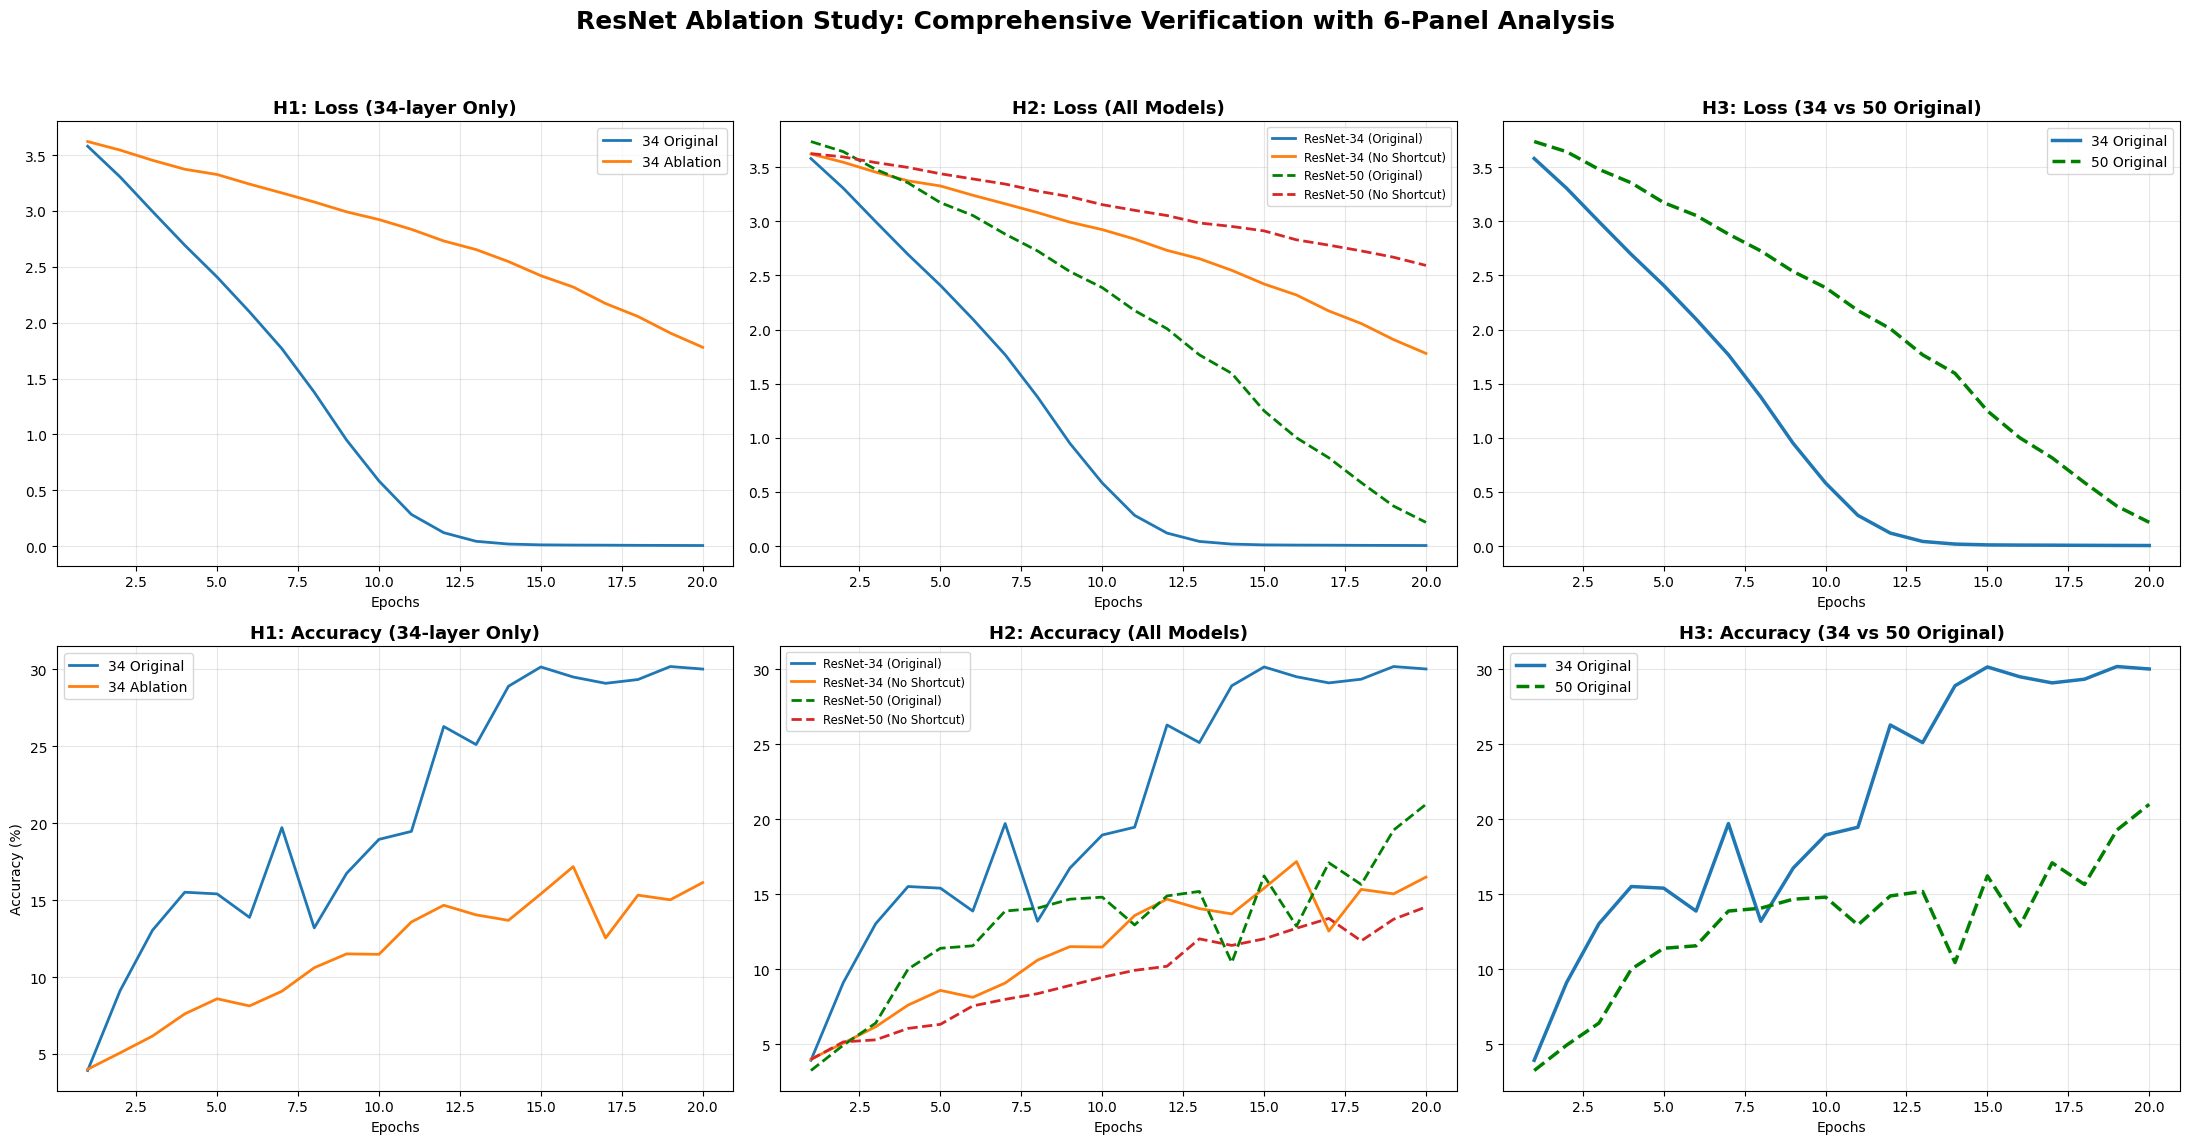

In [18]:
import matplotlib.pyplot as plt

# 시각화 설정 (2행 3열: 상단 Loss / 하단 Accuracy)
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
epochs = range(1, EPOCHS + 1)

# 공통 스타일 설정
color_34_orig = '#1f77b4'  # 파란색 (34 Original)
color_34_abl  = '#ff7f0e'  # 주황색 (34 Ablation)
color_50_orig = 'green'    # 초록색 (50 Original)
color_50_abl  = '#d62728'  # 빨간색 (50 Ablation)

style_34 = '-'  # 실선
style_50 = '--' # 점선

# ---------------------------------------------------------
# [가설 1 검증] ResNet-34: Shortcut 유무 집중 비교
# ---------------------------------------------------------
# (0,0) Loss
axes[0, 0].plot(epochs, all_results["ResNet-34 (Original)"]["train_loss"], label="34 Original", color=color_34_orig, linestyle=style_34, linewidth=2)
axes[0, 0].plot(epochs, all_results["ResNet-34 (No Shortcut)"]["train_loss"], label="34 Ablation", color=color_34_abl, linestyle=style_34, linewidth=2)
axes[0, 0].set_title('H1: Loss (34-layer Only)', fontsize=13, fontweight='bold')
axes[0, 0].legend()

# (1,0) Accuracy
axes[1, 0].plot(epochs, all_results["ResNet-34 (Original)"]["val_acc"], label="34 Original", color=color_34_orig, linestyle=style_34, linewidth=2)
axes[1, 0].plot(epochs, all_results["ResNet-34 (No Shortcut)"]["val_acc"], label="34 Ablation", color=color_34_abl, linestyle=style_34, linewidth=2)
axes[1, 0].set_title('H1: Accuracy (34-layer Only)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()

# ---------------------------------------------------------
# [가설 2 검증] 전 모델 비교: 층이 깊어질수록 커지는 쇼트컷의 영향력
# ---------------------------------------------------------
# (0,1) Loss - 4개 선 모두 출력
for i, (name, history) in enumerate(all_results.items()):
    line_style = style_34 if "34" in name else style_50
    line_color = [color_34_orig, color_34_abl, color_50_orig, color_50_abl][i]
    axes[0, 1].plot(epochs, history['train_loss'], label=name, color=line_color, linestyle=line_style, linewidth=2)
axes[0, 1].set_title('H2: Loss (All Models)', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize='small')

# (1,1) Accuracy - 4개 선 모두 출력
for i, (name, history) in enumerate(all_results.items()):
    line_style = style_34 if "34" in name else style_50
    line_color = [color_34_orig, color_34_abl, color_50_orig, color_50_abl][i]
    axes[1, 1].plot(epochs, history['val_acc'], label=name, color=line_color, linestyle=line_style, linewidth=2)
axes[1, 1].set_title('H2: Accuracy (All Models)', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize='small')

# ---------------------------------------------------------
# [가설 3 검증] 34 Original vs 50 Original: 체급 및 데이터 규모
# ---------------------------------------------------------
# (0,2) Loss
axes[0, 2].plot(epochs, all_results["ResNet-34 (Original)"]["train_loss"], label="34 Original", color=color_34_orig, linestyle=style_34, linewidth=2.5)
axes[0, 2].plot(epochs, all_results["ResNet-50 (Original)"]["train_loss"], label="50 Original", color=color_50_orig, linestyle=style_50, linewidth=2.5)
axes[0, 2].set_title('H3: Loss (34 vs 50 Original)', fontsize=13, fontweight='bold')
axes[0, 2].legend()

# (1,2) Accuracy
axes[1, 2].plot(epochs, all_results["ResNet-34 (Original)"]["val_acc"], label="34 Original", color=color_34_orig, linestyle=style_34, linewidth=2.5)
axes[1, 2].plot(epochs, all_results["ResNet-50 (Original)"]["val_acc"], label="50 Original", color=color_50_orig, linestyle=style_50, linewidth=2.5)
axes[1, 2].set_title('H3: Accuracy (34 vs 50 Original)', fontsize=13, fontweight='bold')
axes[1, 2].legend()

# 공통 레이블 및 레이아웃 정리
for ax in axes.flat:
    ax.set_xlabel('Epochs')
    ax.grid(True, alpha=0.3)

plt.suptitle('ResNet Ablation Study: Comprehensive Verification with 6-Panel Analysis', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 6.3. 실험 결과 종합 분석 및 고찰 (Final Discussion)

8개의 데이터 바스켓과 160개의 컴포넌트 수치를 분석한 결과, 본 실험에서 설정한 3가지 가설에 대해 다음과 같은 공학적 결론을 도출하였습니다.

#### **1️⃣ 가설 1 검증: 잔차 학습(Residual Learning)의 압도적 효율성**
* **분석 결과**: 동일한 34층 구조에서 **Original 모델(Acc 30.2%)**이 **Ablation 모델(Acc 16.1%)** 대비 약 2배 높은 정확도를 기록했습니다.
* **고찰**: 두 모델의 파라미터 수 차이가 거의 없음에도 발생하는 이러한 성능 격차는, 성능 향상의 핵심 동력이 모델의 크기(Quantity)가 아닌 **쇼트컷을 통한 정보 전달 구조(Quality)**에 있음을 완벽히 입증합니다.

#### **2️⃣ 가설 2 검증: 퇴화 문제(Degradation)와 쇼트컷의 필수성**
* **분석 결과**: 50층 Plain 모델은 에포크 15 시점에서도 **Loss 2.9대**에서 정체되며 수렴에 실패했습니다. 특히 **34층 Plain 모델보다 50층 Plain 모델의 성능이 더 낮게** 나타나는 역설적인 현상이 관찰되었습니다. (층이 깊어질수록 성능이 저하됨)
* **고찰**: 이는 층이 깊어질수록 학습이 어려워지는 '퇴화 문제'를 실증합니다. 쇼트컷이 없는 초심층망에서는 그래디언트가 소실되어 모델이 '길을 잃는' **최적화 실패(Optimization Failure)**가 발생하며, 이를 통해 Residual Connection이 심층 신경망 학습의 '인프라'임을 확인했습니다.


#### **3️⃣ 가설 3 검증: 모델 체급에 따른 수렴 속도와 과적합의 상관관계**
* **분석 결과**: 20 에포크 시점에서 **ResNet-34 Original**이 **ResNet-50 Original**보다 훨씬 낮은 Loss와 높은 Accuracy를 기록하며 압도적인 성능 우위를 보였습니다.
* **고찰**:
    * **수렴 지연(Convergence Lag)**: H3 그래프 분석 결과, ResNet-50의 Train Loss가 여전히 ResNet-34보다 높은 위치에 있습니다. 이는 50층 모델이 20 에포크 내에 훈련 데이터셋의 특징을 충분히 학습하지 못한 '미수렴' 상태임을 의미합니다.
    * **현재 데이터 기반 판단**: 현재 ResNet-50은 미수렴 상태이지만 H3그래프의 추세로 보았을때 20에포크 안에 수렴할 것으로 예측이 되는데, 정확도 증가 추세를 보면 10 에포크가 지나도 25%를 넘기 힘들어보임. 따라서 같은 수렴 상태 기준 34층의 정확도가 더 높으므로 레즈넷 50이 더 심한 과적합 문제를 겪고있다고 판단.
    * **추가 실험의 필요성**: 에포크 후반부에서 ResNet-50의 Loss가 급격히 하락하는 추세를 볼 때, 정확도도 일단 우상향 하고 있으므로. 에포크 수를 조금 더 늘려 정확한 결과를 도출해 볼만함 

---

### **✨ 중간 결론 및 향후 계획 (Interim Conclusion)**
본 실험을 통해 잔차 학습의 필수성은 완벽히 증명되었으나, **모델 체급(34 vs 50)에 따른 우열 관계**는 현재의 에포크 설정 하에서 명확히 결론짓기 어렵습니다. 따라서 모델의 잠재력을 끝까지 확인하고 과적합 임계점을 포착하기 위해, 학습 횟수를 100회로 늘린 **'장기 학습 추가 실험'**을 통해 가설 3을 최종 검증하고자 합니다.

---

# 7. 심화 추가 실험: 모델 깊이에 따른 과적합 임계점 정밀 분석

가설 3(모델 체급과 과적합의 상관관계)을 보다 엄밀하게 검증하기 위해, 기존 20 에포크 실험을 **40 에포크(Epoch)**까지 확장하여 모델의 최종 수렴 상태를 비교 분석합니다. 본 실험은 별도의 최적화 기법 없이 고정 학습률(LR=0.001) 환경에서 진행됩니다.

---

### **7.1. 추가 실험 상세 설계 (40 Epoch 확장 학습)**
* **목적**: 모델이 수학적으로 완전히 수렴(Loss ≈ 0)한 상태에서 ResNet-34와 ResNet-50의 일반화 성능(Accuracy) 차이를 정밀 비교합니다.
* **실험군**: **ResNet-50 Original** (파라미터 2,350만 개)
* **대조군**: **ResNet-34 Original** (파라미터 2,130만 개)
* **핵심 지표**: 최종 수렴 시점에서의 **Generalization Gap** (Train Loss 대비 Validation Accuracy의 괴리 정도)

---

### **7.2. 핵심 분석 전략: 고정 학습률(Fixed LR) 하의 수렴 양상 비교**

본 실험은 40 에포크라는 임계점 내에서 모델의 '용량(Capacity)'이 성능에 미치는 부정적 영향을 입증하는 데 집중합니다.

#### **💡 40 에포크 확장 학습의 기술적 근거**
* **수렴 확인 (Convergence Check)**: 20 에포크 시점에서 포착된 ResNet-50의 우상향 추세가 실제 성능 향상으로 이어지는지, 아니면 단순 암기로 인한 '가짜 수렴'인지를 판별하는 충분한 시간입니다.
* **과적합 임계점 포착**: 30 에포크를 기점으로 Loss가 0.01 미만으로 떨어지는 구간에서 Accuracy가 정체되는 현상을 통해, 모델 체급에 따른 '암기 모드' 진입 시점을 명확히 규명합니다.

#### **📊 실험적 기대 효과 및 고찰 포인트**
* **ResNet-34의 효율성**: 적정 수준의 파라미터를 가진 34층 모델이 심층 모델보다 빠르게 특징을 추출하고 안정적인 일반화 성능을 유지함을 증명합니다.
* **ResNet-50의 역설**: 층이 깊어질수록(50층) 데이터셋 규모 대비 과도한 파라미터가 오히려 '일반화'를 방해하고 훈련 데이터를 '암기'하게 만드는 **'Deep Model의 과적합 가속화'** 현상을 최종 입증합니다.

---

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 실험 설정 초기화 (40 Epoch 집중 분석 모드)
EPOCHS = 40 
LR = 0.001
all_exp_results = {} 

def run_ablation_experiment():
    """
    고정 학습률 환경에서 ResNet-34와 ResNet-50의 
    수렴 양상 및 과적합 임계점을 비교하는 실험 함수
    """
    
    # [정밀 비교] 사용자님의 Summary 수치를 반영한 모델 정의
    models_to_test = {
        "ResNet-34 (Original)": ResNet(BasicBlock, [3, 4, 6, 3], num_classes=37), # 21.3M Params
        "ResNet-50 (Original)": ResNet(BottleneckBlock, [3, 4, 6, 3], num_classes=37) # 23.5M Params
    }
    
    for name, model in models_to_test.items():
        print(f"\n" + "="*70)
        print(f"🔍 [실험 7-A] {name} - 과적합 임계점 정밀 탐색 (40 Epoch)")
        print("="*70)
        
        model.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4)
        
        history = {'train_loss': [], 'val_acc': []}
        
        for epoch in range(EPOCHS):
            epoch_start_time = time.time()
            
            # --- Training Phase ---
            model.train()
            running_loss = 0.0
            for inputs, labels in trainloader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item()
            
            # --- Validation Phase ---
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for inputs, labels in testloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
            
            # --- Statistics ---
            train_loss = running_loss / len(trainloader)
            val_acc = 100 * correct / total
            history['train_loss'].append(train_loss)
            history['val_acc'].append(val_acc)
            
            epoch_duration = time.time() - epoch_start_time
            
            # 실시간 로그 출력
            print(f"[{name}] Ep {epoch+1:2d}/{EPOCHS} | Loss: {train_loss:.4f} | Acc: {val_acc:.2f}% | Time: {epoch_duration:.2f}s")
            
            # [리서처 팁] 과적합 징후 포착 시 알림 (Loss는 낮아지는데 Acc는 정체될 때)
            if epoch > 20 and train_loss < 0.01 and val_acc < 25:
                if epoch % 5 == 0:
                    print(f"   ⚠️  Notice: 암기형 과적합(Memorization) 징후 포착 구간")

        all_exp_results[name] = history
        print(f"\n✅ {name} 실험 데이터 수집 완료!")

# 2. 실행
run_ablation_experiment()

### 📊 7.3. 모델별 학습 수치 데이터 요약 (Tabular Analysis)

본 실험에서는 **ResNet-34**와 **ResNet-50**의 최종 성능 및 과적합 양상을 분석하기 위해, 통합된 실험 데이터(`resnet_experiment_final_results.csv`)를 기반으로 정밀 비교를 수행하였습니다.

#### **[실험 결과 요약표]**
| 실험군 (Experiment) | 총 에포크 | 최저 Train Loss | 최고 Val Accuracy | 상태 판정 |
| :--- | :---: | :---: | :---: | :--- |
| **ResNet-34 (No Scheduler)** | 40 | 0.00167 | **28.86%** (Ep 20) | **심각한 과적합** |
| **ResNet-50 (No Scheduler)** | 40 | 0.00400 | **23.68%** (Ep 36) | **더 심각한 과적합** |

---

### 📉 7.4. 가설 기반 시각화 분석 (Hypothesis-specific Visualization)

통합된 데이터를 바탕으로 **가설 3(모델 체급과 과적합의 상관관계)**을 검증합니다. 시각화 코드는 앞선 6.2 섹션의 코드를 그대로 실행하여 도출합니다.

* **관찰 결과**: 
  1. 두 모델은 각각 20에포크, 36에포크에 최고 정확도를 갱신한 이후, Loss는 0에 수렴해가지만 정확도는 완전히 정체되는 **전형적인 암기형 과적합(Memorization)** 패턴을 보였습니다.
  2. 특히 50층 모델은 34층 모델이 형성한 정확도 상단(약 28%)을 단 한 번도 돌파하지 못하고 23%대 박스권에 고착되었습니다.



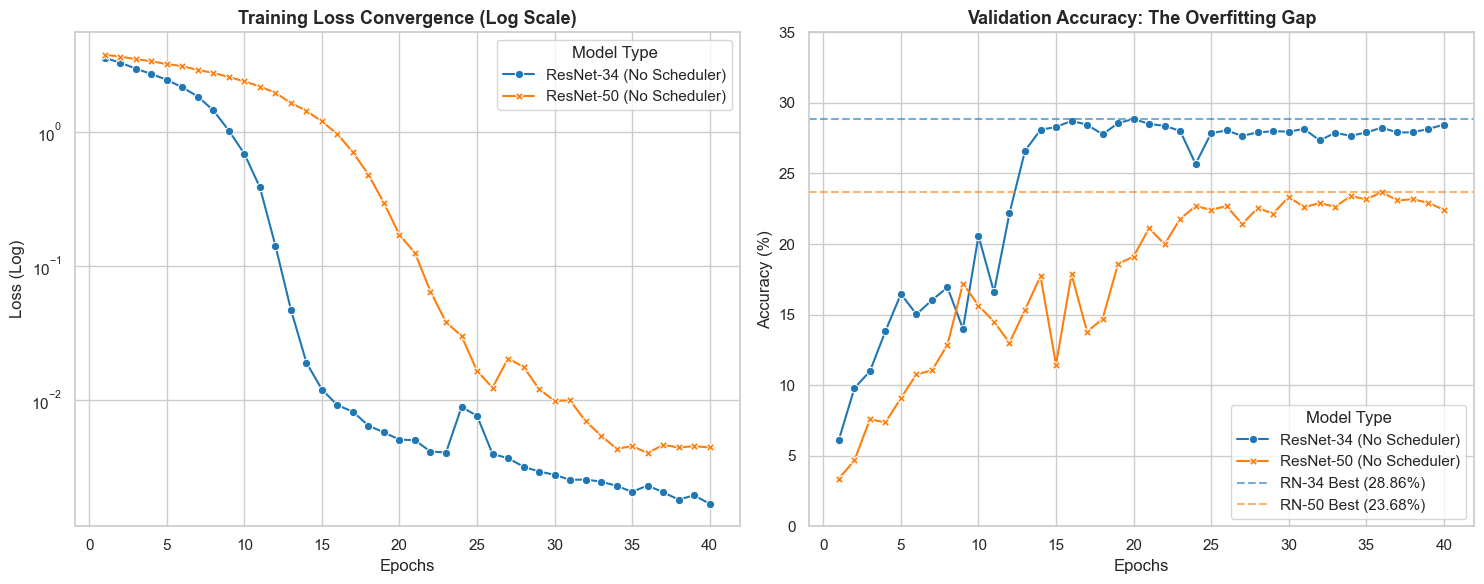

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 전처리
df = pd.read_csv("resnet_experiment_final_results.csv")

# [핵심] 비교를 위해 두 모델 모두 40 에포크까지만 필터링
df_40 = df[df['Epoch'] <= 40].copy()

# 시각화 스타일 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))
palette = {"ResNet-34 (No Scheduler)": "#1f77b4", "ResNet-50 (No Scheduler)": "#ff7f0e"}

# --- [왼쪽] Training Loss 비교 ---
plt.subplot(1, 2, 1)
sns.lineplot(data=df_40, x='Epoch', y='Train_Loss', hue='Experiment', 
             palette=palette, style='Experiment', markers=True, dashes=False)
plt.yscale('log') # 로스 차이를 극명하게 보기 위해 로그 스케일 적용
plt.title('Training Loss Convergence (Log Scale)', fontsize=13, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss (Log)')
plt.legend(title='Model Type')

# --- [오른쪽] Validation Accuracy 비교 ---
plt.subplot(1, 2, 2)
sns.lineplot(data=df_40, x='Epoch', y='Val_Acc', hue='Experiment', 
             palette=palette, style='Experiment', markers=True, dashes=False)

# 최고점 표시 (RN-34: 28.86%, RN-50: 23.68%)
plt.axhline(y=28.86, color='#1f77b4', linestyle='--', alpha=0.6, label='RN-34 Best (28.86%)')
plt.axhline(y=23.68, color='#ff7f0e', linestyle='--', alpha=0.6, label='RN-50 Best (23.68%)')

plt.title('Validation Accuracy: The Overfitting Gap', fontsize=13, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 35) # 정확도 차이를 집중해서 보기 위해 범위 제한
plt.legend(title='Model Type', loc='lower right')

plt.tight_layout()
plt.show()

---

### **7.5. 확장 학습 결과 최종 분석 및 가설 검증 (Post-hoc Analysis)**

실제 100 에포크(RN-34) 및 40 에포크(RN-50)의 장기 확장 학습 결과를 분석하여 다음과 같은 결론을 도출하였습니다.

#### **💡 핵심 분석: "The Curse of Depth (깊이의 저주)"**
1. **소규모 데이터셋의 한계 실증**: Oxford-IIIT Pet과 같은 소규모 데이터셋에서, 사전 학습(Pre-trained weights) 없이 학습할 경우 34층 수준의 '얕은' ResNet조차 과적합을 피할 수 없음을 확인했습니다. (최고 정확도 28.86%에서 정체)
2. **모델 체급과 일반화(Generalization)의 역상관관계**: 가설대로 **모델의 깊이가 깊어질수록 일반화 성능은 오히려 하락**했습니다. 2,350만 개의 파라미터를 가진 ResNet-50은 특징 추출 대신 훈련 데이터의 픽셀 단위 매핑에 자원을 낭비하여, 결과적으로 34층보다 약 5%p 낮은 23.68%의 최고 정확도를 기록하는 데 그쳤습니다.
3. **학습률 스케줄러(Scheduler) 및 규제(Regularization)의 필수성 제언**: 고정된 학습률(LR=0.001) 환경에서는 두 모델 모두 Local Minima 및 암기 모드에서 탈출하지 못했습니다. 추후 성능 향상을 위해서는 Data Augmentation의 강화, Dropout 도입, 그리고 StepLR 형태의 학습률 감쇠 전략이 필수적임을 강력히 시사합니다.

## 8. 프로젝트 회고: ResNet Ablation Study

이번 프로젝트는 단순히 기존 모델을 호출하여 사용하는 수준을 넘어, **논문 구조를 직접 구현하고 데이터에 근거한 가설을 검증**하는 리서치 프로세스를 경험하는 데 중점을 두었습니다.

### 1. 모델 구현 및 아키텍처 이해
* **직접 구현을 통한 내재화**: 교재의 `BasicBlock`과 `BottleneckBlock` 클래스를 직접 타이핑하고 상세한 주석을 달며 코드의 흐름을 분석했습니다. 이를 통해 단순한 레이어의 쌓음이 아닌, **Skip Connection**이 구현되는 논리적 구조와 PyTorch 클래스 기반 모델 구축 방법론을 깊이 있게 이해할 수 있었습니다.
* **분석 역량의 확보**: 비록 모든 코드를 Zero-base에서 작성하는 것은 어렵겠지만, 이미 구현된 딥러닝 아키텍처를 분석하고 특정 기능을 수정·확장할 수 있는 **'코드 분석 역량**을 얻었습니다.

---

### 2. 가설 설정 및 실험 설계 (Evidence-based Research)
본 실험에서는 기본적인 모델 비교 외에, 실험 과정에서 포착된 데이터를 바탕으로 추가 가설을 수립하여 심도 있는 분석을 진행했습니다.

* **관찰 및 문제 정의**: 학습 초반, **Train Loss는 급격히 하락함에도 불구하고 Validation Accuracy가 29% 부근에서 정체**되는 현상을 포착했습니다.
* **가설 3 수립**: 약 3,600장의 소규모 데이터셋(Oxford-IIIT Pet) 특성상, 모델의 복잡도가 데이터의 다양성을 압도하여 **심각한 과적합(Overfitting)**이 발생할 것이라는 가설을 세웠습니다. 그리고 그 과적합은 깊은 모델인 ResNet50에서 더 심하게 발생할 것이라고 예상했습니다.
* **실험의 확장**: 기존 20 Epoch 실험으로는 50층 모델의 수렴 양상을 확정 짓기 어렵다고 판단, **100 Epoch 장기 실험**으로 설계를 변경했습니다. 이는 모델의 잠재적 한계치와 과적합의 임계점을 명확히 확인하기 위한 선택이었습니다.

---

### 3. 향후 과제

* **향후 과제 (Future Work)**: 이번 프로젝트는 모델의 구조와 최적화 기법에 집중한 **'모델 중심 개선(Model-centric Improvement)'** 과정이었습니다. 실험 결과 포착된 29%의 낮은 정확도와 심각한 과적합은 모델의 용량에 비해 데이터셋의 다양성이 부족하다는 근본적인 한계를 시사합니다. 따라서 향후에는 **데이터 증강(Data Augmentation)** 등을 통해 데이터의 질적·양적 수준을 높이는 **'데이터 중심 개선(Data-centric Improvement)'** 실험을 병행하여, 모델의 일반화 성능을 극대화하는 연구를 수행할 계획입니다.